# Modelo de clasificación en Riesgo de Crédito

## El Problema de Negocio:
Imagina que trabajas en el departamento de Riesgos de un banco. Cada día llegan miles de solicitudes de tarjetas de crédito. Aprobar a un cliente que luego no paga (moroso) le cuesta mucho dinero al banco. Rechazar a un buen cliente significa perder ingresos y dárselos a la competencia. 

## Objetivo:
Construir un modelo de Machine Learning capaz de clasificar si un cliente es de "Alto Riesgo" (```Label``` = 1) o "Bajo Riesgo" (``Label`` = 0) basándonos en sus datos demográficos y financieros antes de concederle la tarjeta. 

## Marco de Coste de Negocio

Vamos a asignar un coste aproximado (ilustrativo, no oficial del banco) a cada tipo de error, para poder traducir cualquier métrica a dólares en cualquier punto del análisis:

- **Falso Negativo (FN):** aprobamos una tarjeta a alguien que termina siendo moroso. Coste: el capital que el banco pierde de golpe. Lo fijamos en **8.000$** de media por caso.

- **Falso Positivo (FP):** rechazamos a un cliente que en realidad era bueno pagador. Coste: el margen de intereses que dejamos de ganar y que probablemente se lleva la competencia. Lo fijamos en **400$** de media por caso.

La proporción (20:1) no es casualidad. En riesgo de crédito, un impago suele doler bastante más que un rechazo de más. Este marco es exactamente lo que vamos a usar más adelante para elegir el umbral de decisión y para la traducción final a euros de cada modelo.

## El Contexto de Negocio

Imagina que trabajas en el departamento de Admisión de Riesgos de un banco. Cada día, miles de clientes solicitan una nueva tarjeta de crédito a través de la app. El problema es crítico: cada vez que el banco le da una tarjeta a un cliente que luego no paga (moroso), se pierden miles de euros de golpe. Pero si el banco se asusta y rechaza a los buenos clientes, le está regalando el negocio y los intereses a la competencia.

La dirección te ha entregado un histórico de clientes reales. Su objetivo es claro: necesitan un modelo de *Credit Scoring* automático que sea capaz de predecir si un solicitante es de Alto Riesgo o Bajo Riesgo en tiempo real, antes de concederle el dinero.

### Importamos librerias

In [175]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import  RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

import warnings
warnings.filterwarnings('ignore')

# Tema visual oscuro
plt.style.use('default')

plt.rcParams.update({
    'figure.figsize': (5, 4),

    'axes.facecolor': '#FFFFFF',
    'figure.facecolor': '#FFFFFF',

    'axes.edgecolor': '#D0D7DE',

    'grid.color': '#E5E7EB',
    'grid.linestyle': '--',
    'grid.alpha': 0.8,

    'font.size': 10,
})

Definimos costes de cada decisión

In [176]:
COSTE_FALSO_NEGATIVO = 8000   # $ perdidos por aprobar a un moroso
COSTE_FALSO_POSITIVO = 400    # $ de oportunidad perdidos por rechazar a un buen cliente

print(f"Ratio de coste FN/FP: {COSTE_FALSO_NEGATIVO / COSTE_FALSO_POSITIVO:.0f}:1")

Ratio de coste FN/FP: 20:1


In [177]:
# carga de los CSV y hacemos merge por la columna en comun Ind_ID
df_features = pd.read_csv("../data/raw/Credit_card.csv")
df_labels = pd.read_csv("../data/raw/Credit_card_label.csv")

df = pd.merge(df_features, df_labels, on="Ind_ID", how="inner")

Antes de continuar, verificamos si hicimos bien el merge de las dos tablas con el fin de observar si no obviamos alguna filas, ademas de analizar si existen filas duplicadas. 

In [178]:
ids_solo_features = set(df_features["Ind_ID"]) - set(df_labels["Ind_ID"]) 
ids_solo_labels = set(df_features["Ind_ID"]) - set(df_labels["Ind_ID"])

# validación de duplicados
duplicados_features = df_features['Ind_ID'].duplicated().sum()
duplicados_labels = df_labels['Ind_ID'].duplicated().sum()

# Filas perdidas
filas_perdidas = len(df_features) - len(df)

print(f"Clientes con datos pero sin etiqueta de riesgo: {len(ids_solo_features)}")
print(f"Clientes con etiquetas pero sin datos: {len(ids_solo_labels)}")

print(f"IDs duplicados en features: {duplicados_features}")
print(f"IDs duplicados en labels: {duplicados_labels}")

print(f"\nFilas descartadas por el inner join: {filas_perdidas} ({100*filas_perdidas/len(df_features):.2f}% del total)")

Clientes con datos pero sin etiqueta de riesgo: 0
Clientes con etiquetas pero sin datos: 0
IDs duplicados en features: 0
IDs duplicados en labels: 0

Filas descartadas por el inner join: 0 (0.00% del total)


Ahora renombramos las variables para mayor comodidad y consistencia a la hora de hacer el anlaisis exploratorio. 

In [179]:
df = df.rename(columns={
    'Ind_ID'        :   'id',
    'GENDER'        :   'gender',
    'Car_Owner'     :   'car_owner',
    'Propert_Owner' :   'propert_owner',
    'CHILDREN'      :   'children',
    'Annual_income' :   'annual_income',
    'Type_Income'   :   'type_income',
    'EDUCATION'     :   'education',
    'Marital_status':   'marital_status',
    'Housing_type'  :   'housing_type',
    'Birthday_count':   'birthday_count',
    'Employed_days' :   'employed_days',
    'Mobile_phone'  :   'mobile_phone',
    'Work_Phone'    :   'work_phone',
    'Phone'         :   'phone',
    'EMAIL_ID'      :   'email_id',
    'Type_Occupation':  'type_occupation',
    'Family_Members':   'family_members'

})
df.head()

,id,gender,car_owner,propert_owner,children,annual_income,type_income,education,marital_status,housing_type,birthday_count,employed_days,mobile_phone,work_phone,phone,email_id,type_occupation,family_members,label
0,5008827,M,Y,Y,0,180000.0,Pensioner,Higher education,Married,House / apartment,-18772.0,365243,1,0,0,0,NaN,2,1
1,5009744,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2,1
2,5009746,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,NaN,-586,1,1,1,0,NaN,2,1
3,5009749,F,Y,N,0,NaN,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2,1
4,5009752,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2,1


## Exploraremos las variables

Analizaremos algunas correlaciones de las variables para tomar mejores decisiones de imputación. 

Observamos que la distribución de pagadores no esta equilibrada, por un lado vemos que la basta mayoria 88% son buenos pagadores;sin embargo, tenemos una minoria del 11% que no son buenos pagadores. 

label
0    0.886951
1    0.113049
Name: proportion, dtype: float64


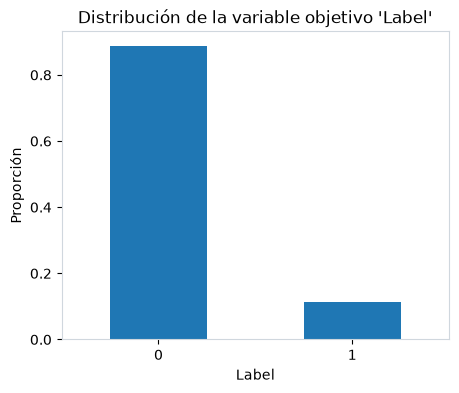

In [180]:
print(df["label"].value_counts(normalize=True))

df["label"].value_counts(normalize=True).plot(kind="bar")

plt.title("Distribución de la variable objetivo 'Label'")
plt.xlabel("Label")
plt.ylabel("Proporción")
plt.xticks(rotation=0)
plt.show()

En el análisis descriptivo observamos variables de propiedad `car_owner`, `propert_owner` `email_id`,`work_phone`,`phone`,`mobile_phone` veremos si tiene relación con ser un buen pagador o no. 

In [181]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,1548.0,5.078920e+06,41717.587742,5008827.0,5045069.75,5078841.5,5115673.00,5150412.0
children,1548.0,4.127907e-01,0.776691,0.0,0.00,0.0,1.00,14.0
annual_income,1525.0,1.913993e+05,113252.997656,33750.0,121500.00,166500.0,225000.00,1575000.0
birthday_count,1526.0,-1.604034e+04,4229.503202,-24946.0,-19553.00,-15661.5,-12417.00,-7705.0
employed_days,1548.0,5.936469e+04,137808.062701,-14887.0,-3174.50,-1565.0,-431.75,365243.0
mobile_phone,1548.0,1.000000e+00,0.000000,1.0,1.00,1.0,1.00,1.0
work_phone,1548.0,2.080103e-01,0.406015,0.0,0.00,0.0,0.00,1.0
phone,1548.0,3.094315e-01,0.462409,0.0,0.00,0.0,1.00,1.0
email_id,1548.0,9.237726e-02,0.289651,0.0,0.00,0.0,0.00,1.0
family_members,1548.0,2.161499e+00,0.947772,1.0,2.00,2.0,3.00,15.0


Verificamos el formato de nuestras variables, parece todo estar correcto. Y eliminamos `id` ya que solo este es un identificador. 

In [182]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1548 entries, 0 to 1547
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1548 non-null   int64  
 1   gender           1541 non-null   str    
 2   car_owner        1548 non-null   str    
 3   propert_owner    1548 non-null   str    
 4   children         1548 non-null   int64  
 5   annual_income    1525 non-null   float64
 6   type_income      1548 non-null   str    
 7   education        1548 non-null   str    
 8   marital_status   1548 non-null   str    
 9   housing_type     1548 non-null   str    
 10  birthday_count   1526 non-null   float64
 11  employed_days    1548 non-null   int64  
 12  mobile_phone     1548 non-null   int64  
 13  work_phone       1548 non-null   int64  
 14  phone            1548 non-null   int64  
 15  email_id         1548 non-null   int64  
 16  type_occupation  1060 non-null   str    
 17  family_members   1548 non

In [183]:
df.drop("id", axis=1, inplace=True)

verificaremos los nulos. Vemos que tenemos una variable con muchos nulos `type_occupation` - En este punto nace una pregunta imporante: ¿El cliente esta desempleado, por eso la la casilla es nula? 

In [184]:
df.isnull().sum()

gender               7
car_owner            0
propert_owner        0
children             0
annual_income       23
type_income          0
education            0
marital_status       0
housing_type         0
birthday_count      22
employed_days        0
mobile_phone         0
work_phone           0
phone                0
email_id             0
type_occupation    488
family_members       0
label                0
dtype: int64

Demos un vistazo general de los valores únicos de las variables categóricas. Vemos que variables como `type_occupation` , `housing_type` & `education` podemos agrupar algunos de sus elementos sin agregar mucho ruido. 

In [185]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

for cat in cat_cols:
    print("-----")
    print(df[cat].value_counts(dropna=False))
    print()

-----
gender
F      973
M      568
NaN      7
Name: count, dtype: int64

-----
car_owner
N    924
Y    624
Name: count, dtype: int64

-----
propert_owner
Y    1010
N     538
Name: count, dtype: int64

-----
type_income
Working                 798
Commercial associate    365
Pensioner               269
State servant           116
Name: count, dtype: int64

-----
education
Secondary / secondary special    1031
Higher education                  426
Incomplete higher                  68
Lower secondary                    21
Academic degree                     2
Name: count, dtype: int64

-----
marital_status
Married                 1049
Single / not married     227
Civil marriage           101
Separated                 96
Widow                     75
Name: count, dtype: int64

-----
housing_type
House / apartment      1380
With parents             80
Municipal apartment      53
Rented apartment         21
Office apartment          9
Co-op apartment           5
Name: count, dtype: int64

--

## Análisis exploratorio de variables (EDA)

Definimos nuestras variables categóricas y numéricas para facilitar el análisi, observamos que las variables binarias son consideradas como categóricas. Convertiremos sus valores para que sean consideradas binarias en `Y/N` a `1/0`

In [186]:
# Definimos variables categoricas y numericas
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Variables categóricas: {cat_cols}")
print(f"Variables numéricas: {num_cols}")

Variables categóricas: ['gender', 'car_owner', 'propert_owner', 'type_income', 'education', 'marital_status', 'housing_type', 'type_occupation']
Variables numéricas: ['children', 'annual_income', 'birthday_count', 'employed_days', 'mobile_phone', 'work_phone', 'phone', 'email_id', 'family_members', 'label']


In [187]:
cols = ['car_owner', 'propert_owner']
df[cols] = df[cols].replace({'Y': 1 , 'N': 0}).astype('int64')

CAT_COLS = ['gender', 'type_income', 'education', 'marital_status', 'housing_type', 'type_occupation']
NUM_COLS = ['children', 'annual_income', 'birthday_count', 'employed_days', 'family_members']
BIN_COLS = ['car_owner', 'propert_owner','mobile_phone', 'work_phone','phone', 'email_id']

print(f"Variables categóricas: {CAT_COLS}")
print(f"Variables numéricas: {NUM_COLS}")
print(f"Variables binarias: {BIN_COLS}")

Variables categóricas: ['gender', 'type_income', 'education', 'marital_status', 'housing_type', 'type_occupation']
Variables numéricas: ['children', 'annual_income', 'birthday_count', 'employed_days', 'family_members']
Variables binarias: ['car_owner', 'propert_owner', 'mobile_phone', 'work_phone', 'phone', 'email_id']


In [188]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1548 entries, 0 to 1547
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   gender           1541 non-null   str    
 1   car_owner        1548 non-null   int64  
 2   propert_owner    1548 non-null   int64  
 3   children         1548 non-null   int64  
 4   annual_income    1525 non-null   float64
 5   type_income      1548 non-null   str    
 6   education        1548 non-null   str    
 7   marital_status   1548 non-null   str    
 8   housing_type     1548 non-null   str    
 9   birthday_count   1526 non-null   float64
 10  employed_days    1548 non-null   int64  
 11  mobile_phone     1548 non-null   int64  
 12  work_phone       1548 non-null   int64  
 13  phone            1548 non-null   int64  
 14  email_id         1548 non-null   int64  
 15  type_occupation  1060 non-null   str    
 16  family_members   1548 non-null   int64  
 17  label            1548 non

Ahora analizamos los valores únicos de estas variables, para ver si existe algún error de tipeo. Bien Observamos que `mobile_phone` solo cuenta con elemento, podemos eliminarlo ya que no afectara a nuestro modelo. 

In [189]:
for c in BIN_COLS:
    print(c, df[c].unique())

car_owner [1 0]
propert_owner [1 0]
mobile_phone [1]
work_phone [0 1]
phone [0 1]
email_id [0 1]


In [190]:
# Eliminamos la variable mobile_phone
df.drop('mobile_phone', axis=1, inplace=True)

Ahora analicemos la estadística descriptiva de las variables numéricas. Aquí me nace una duda, si la variable `children` y `familia_members` estan correlacionadas. 

In [191]:
df[NUM_COLS].describe()

,children,annual_income,birthday_count,employed_days,family_members
count,1548.000000,1.525000e+03,1526.000000,1548.000000,1548.000000
mean,0.412791,1.913993e+05,-16040.342071,59364.689922,2.161499
std,0.776691,1.132530e+05,4229.503202,137808.062701,0.947772
min,0.000000,3.375000e+04,-24946.000000,-14887.000000,1.000000
25%,0.000000,1.215000e+05,-19553.000000,-3174.500000,2.000000
50%,0.000000,1.665000e+05,-15661.500000,-1565.000000,2.000000
75%,1.000000,2.250000e+05,-12417.000000,-431.750000,3.000000
max,14.000000,1.575000e+06,-7705.000000,365243.000000,15.000000


In [192]:
print(df['children'].value_counts().sort_index())
print(df['family_members'].value_counts().sort_index())

children
0     1091
1      305
2      134
3       16
4        1
14       1
Name: count, dtype: int64
family_members
1     334
2     802
3     268
4     127
5      15
6       1
15      1
Name: count, dtype: int64


In [193]:
df.groupby(['family_members', 'children'])['children'].agg(['count']).reset_index()

,family_members,children,count
0,1,0,332
1,1,1,2
2,2,0,759
3,2,1,43
4,3,1,260
5,3,2,8
6,4,2,126
7,4,3,1
8,5,3,15
9,6,4,1


Efectivamente, las variables `family_members` y `childnre` estan correlacionadas de algún modo. Esto lo trataremos mas adelante con el VIF, y decidiremos si eliminarlo o no. Además vemos que muchas familias sin hijos o son unico miembro de una familia. 

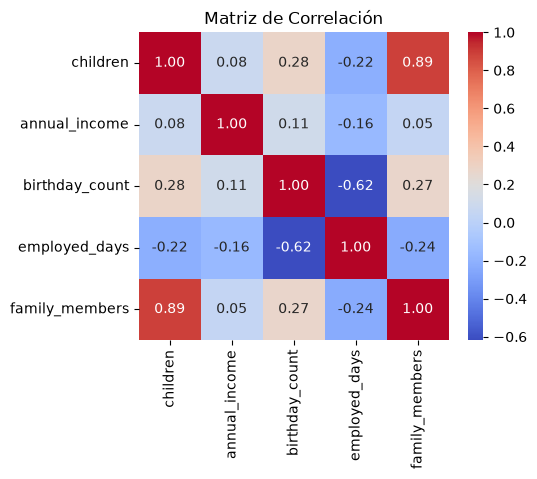

In [194]:
correlation_matrix = df[NUM_COLS].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlación")
plt.show()

Vemos que existe más cantidad de mujeres que optan por tener una tarjeta de crédito. Y además que la mayoria no es dueño de un vehículo; sin embargo, la mayoria es dueño de una propiedad, que probablemente sirva para garantizar que un usuario sea buen pagador. 

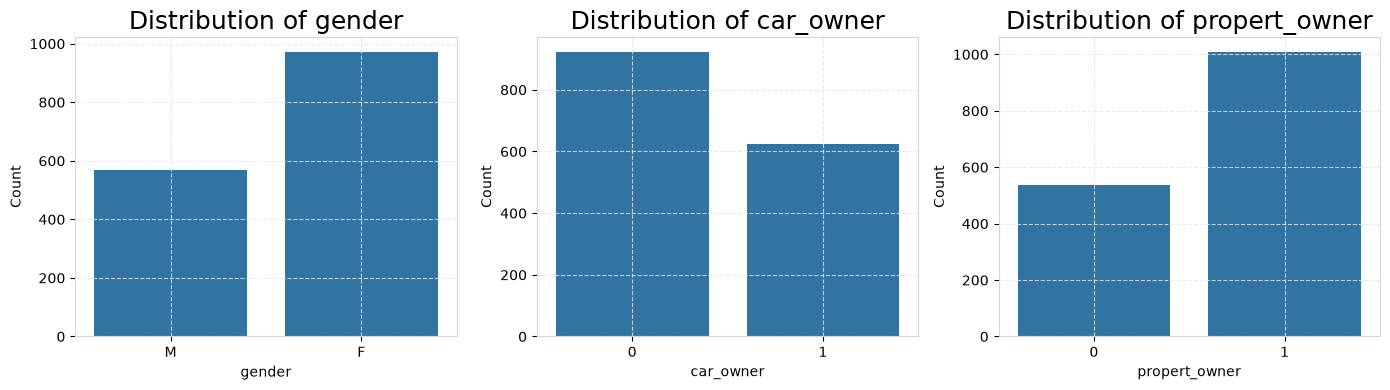

In [195]:
cols = ['gender', 'car_owner', 'propert_owner']

# Set up the figure and axes

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(14, 4))

# Plot univariate distributions for each column
for i, col in enumerate(cols):
    sns.countplot(data=df , x=col, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}' , fontsize=18 )
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x')
    axes[i].grid(True)

plt.tight_layout()
plt.show()

Pues parece que no existe ningún patron interesante para inputar la variable `annual_income`, podemos imputarlo usando la mediana. Además, observamos que tiene algunos outliers una amplia cola a la derecha. 

In [196]:
df.loc[df["annual_income"].isna(), "type_income"].value_counts()

type_income
Working                 11
Commercial associate     8
Pensioner                4
Name: count, dtype: int64

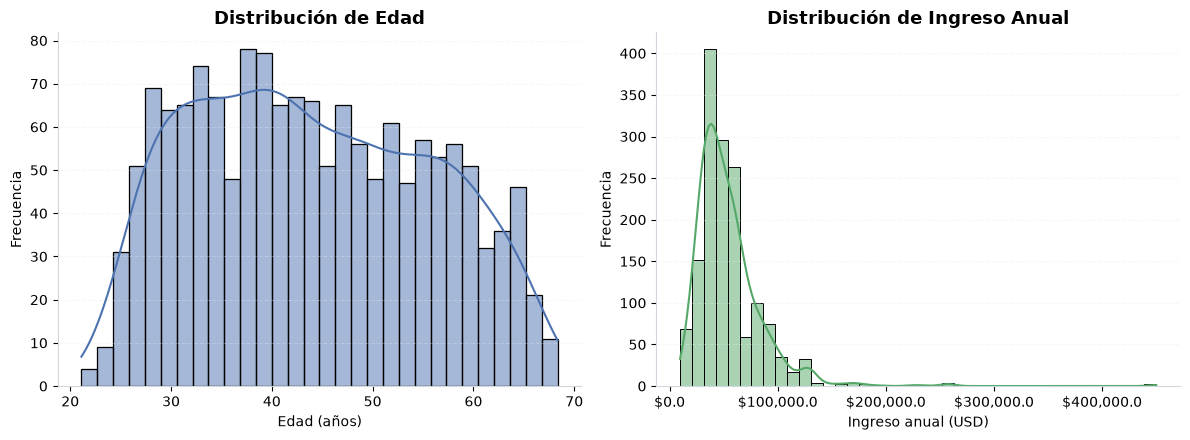

In [197]:
from matplotlib.ticker import FuncFormatter

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Distribucion de edad
age_tmp = -df['birthday_count'] / 365

sns.histplot(age_tmp.dropna(),bins=30,kde=True,ax=axes[0],color = '#4C72B0')

axes[0].set_title('Distribución de Edad',fontsize=13,fontweight='bold')
axes[0].set_xlabel('Edad (años)')
axes[0].set_ylabel('Frecuencia')

# Distribucion ingreso anual
exchange_rate = 3.50

income_usd = df['annual_income'] / exchange_rate

sns.histplot(income_usd.dropna(),bins=40,kde=True,ax=axes[1],color='#55A868')

axes[1].set_title('Distribución de Ingreso Anual',fontsize=13,fontweight='bold')
axes[1].set_xlabel('Ingreso anual (USD)')
axes[1].set_ylabel('Frecuencia')

# Formato del eje X del ingreso
axes[1].xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'${x:,.1f}'))

for ax in axes:
    ax.grid(axis='y',linestyle='--',alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Seguimos con `birthday_count` y vemos que no existe algun tipo de patron interesante, porque cual imputaremos por la mediana. 

In [198]:
df[df['birthday_count'].isna()][['employed_days']].value_counts().reset_index()

,employed_days,count
0,365243,4
1,-586,1
2,-508,1
3,-583,1
4,-1190,1
5,-6908,1
6,-2052,1
7,-2276,1
8,-6693,1
9,-2959,1


Ahora agrupemos el tipo de ocupacion por el tipo de ingreso `type_occupation` & `type_income` en especial los valores nulos para tener alguna idea de que se podria imputar. Evidentemente, tenemos que `pensioner` con mas cantidad de valores faltantes, eso tendría sentido agruparlos como desconocidos, ya que un pensionistas se puede dedicar a diferentes actividades.

In [199]:
df[df['type_occupation'].isna()]['type_income'].value_counts()

type_income
Pensioner               264
Working                 129
Commercial associate     77
State servant            18
Name: count, dtype: int64

In [200]:
df.groupby(['type_income', 'education'])['label'].mean().sort_values(ascending=False).reset_index()

,type_income,education,label
0,Commercial associate,Lower secondary,0.500000
1,Working,Lower secondary,0.333333
2,Pensioner,Higher education,0.212766
3,Commercial associate,Higher education,0.194444
4,Pensioner,Secondary / secondary special,0.146226
5,Pensioner,Lower secondary,0.142857
6,Working,Incomplete higher,0.117647
7,Commercial associate,Secondary / secondary special,0.102564
8,Working,Secondary / secondary special,0.100358
9,State servant,Higher education,0.093023


Vemos que los pensionistas & los que son baja secundaria son los que tienen mayor tasa de morosidad. 

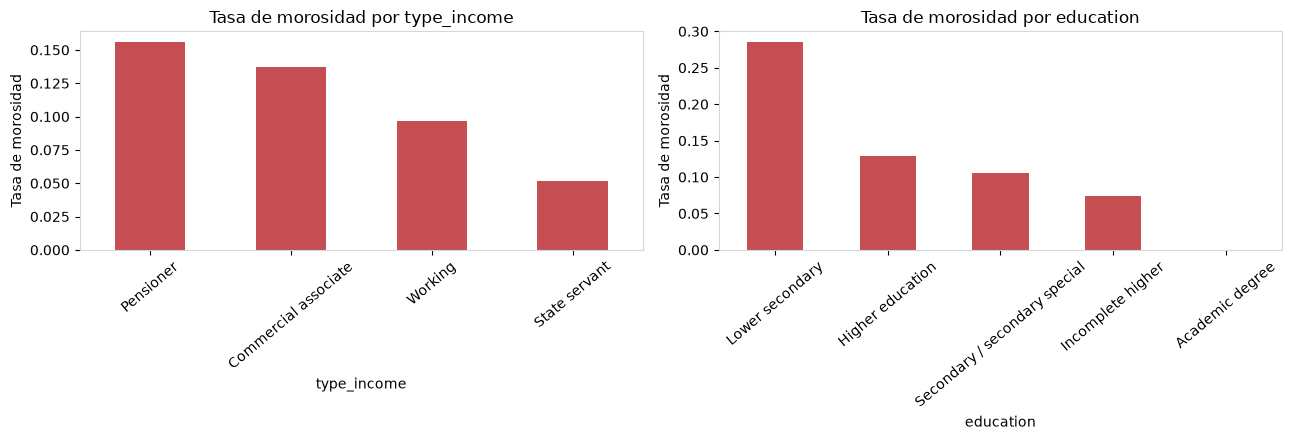

In [201]:
# Tasa de morosidad por variable categorica
fig, axes = plt.subplots(1, 2, figsize=(13,4.5))
for ax, col in zip(axes, ['type_income', 'education']):
    rate = df.groupby(col)['label'].mean().sort_values(ascending=False)
    rate.plot(kind='bar', ax=ax, color='#C44E52')
    ax.set_ylabel('Tasa de morosidad')
    ax.set_title(f'Tasa de morosidad por {col}')
    ax.tick_params(axis='x', rotation=40)
plt.tight_layout(); plt.show()

Siguiendo la dinánima del análisis, vemos que la variable `employed_days` tiene un valor de `365243.000000`. Exploraremos un poco más de que trata, y luego veremos si la variable tiene alguna relación con el `type_income`

In [202]:
df['employed_days'].describe()

count      1548.000000
mean      59364.689922
std      137808.062701
min      -14887.000000
25%       -3174.500000
50%       -1565.000000
75%        -431.750000
max      365243.000000
Name: employed_days, dtype: float64

Según el diccionario, vemos que la variable `employed_dias` enumera con negativo los dias que un usuario tiene en el mundo laboral. Por otra parte, vemos que no existe valores distintos de `365243`, lo que nos da entender como un codigo único de clasificación.

In [203]:
print(df['employed_days'].value_counts())


employed_days
 365243    261
-586         6
-3420        5
-622         5
-460         5
          ... 
-1648        1
-3536        1
-2182        1
-1209        1
-2859        1
Name: count, Length: 956, dtype: int64


In [204]:
df.loc[df['employed_days'] > 0, 'employed_days' ].value_counts()

employed_days
365243    261
Name: count, dtype: int64

Ahora veremos si ese codigo `365243` tiene alguna tipo de relación con el `type_income`. Como habiamos visto anteriormente, que podemos imputar algunos valores faltantes con la etiqueta de retirado o desempleado, ya que son pensionistas.

In [205]:
df[df['employed_days'] == 365243]['type_income'].value_counts()

type_income
Pensioner    261
Name: count, dtype: int64

## Limpieza básica

La variable `employed_days` tiene un codigo especial para identificar a los retirados, crearemos una nueva variable para identificar a los retirados y desempleados con 1 y los trabajadores con 0. Ademas, imputaremos ese codigo especial con 0, ya que nos da a entender que si un usuario no trabaja, por ahora colocaremos nan y después lo imputaremos

In [206]:

df['is_retired_unemployed'] =(df['employed_days'] == 365243).astype(int)

df.loc[df['employed_days'] == 365243, 'employed_days'] = np.nan

df.employed_days.isnull().sum()

np.int64(261)

Ahora agruparemos las categorias del modo que tenga sentido sin alterar ni agregar ruido. 

In [207]:

occ_counts = df['type_occupation'].value_counts()
rare_occ = occ_counts[occ_counts < 20].index.tolist()

print("Ocupaciones agrupadas en 'Other':", rare_occ)
df['type_occupation'] = df['type_occupation'].replace(rare_occ, 'Other')
df['type_occupation'] = df['type_occupation'].fillna('Unknown')

Ocupaciones agrupadas en 'Other': ['Private service staff', 'Low-skill Laborers', 'Secretaries', 'Waiters/barmen staff', 'HR staff', 'IT staff', 'Realty agents']


Bien, ahora hechemos un vistazo a las variables categoricas. Vemos que existe muchas categorias, por ejemplo podemos agrupar `education` y `housing_type`

In [208]:
CAT_COLS = ['gender', 'type_income', 'education', 'marital_status', 'housing_type', 'type_occupation']
NUM_COLS = ['children', 'annual_income', 'birthday_count', 'employed_days', 'family_members']
BIN_COLS = ['car_owner', 'propert_owner','work_phone','phone', 'email_id', 'is_retired_unemployed']


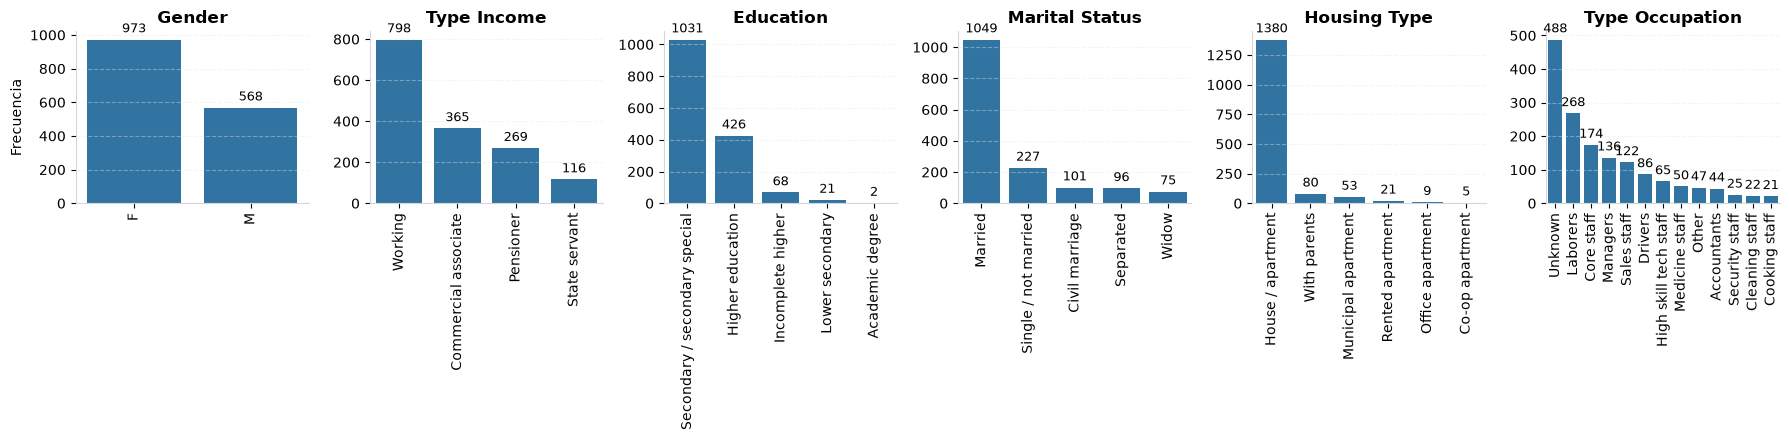

In [209]:
fig, axes = plt.subplots(
    ncols=6,
    nrows=1,
    figsize=(18, 4.5)
)

axes = axes.flatten()

for i, col in enumerate(CAT_COLS):

    sns.countplot(
        data=df,
        x=col,
        ax=axes[i],
        order=df[col].value_counts().index
    )

    axes[i].set_title(
        col.replace('_', ' ').title(),
        fontsize=12,
        fontweight='bold'
    )

    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frecuencia' if i == 0 else '')

    # Rotar etiquetas
    axes[i].tick_params(
        axis='x',
        rotation=90
    )

    # Cuadrícula horizontal
    axes[i].grid(
        axis='y',
        linestyle='--',
        alpha=0.4
    )

    # Quitar bordes superiores y derechos
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

    # Agregar valores encima de las barras
    for container in axes[i].containers:
        axes[i].bar_label(
            container,
            fmt='%d',
            padding=3,
            fontsize=9
        )

plt.tight_layout()
plt.show()

Hacemos lo mismo con `educacion` 

In [210]:
df['education'] = df['education'].replace('Academic degree', 'Higher education')
# df['education'] = df['education'].replace(['Lower secondary', 'Secondary / secondary special'], 'Secondary')
df.groupby('education')['label'].agg(['mean', 'count']).sort_values('count', ascending=False)

,mean,count
education,,
Secondary / secondary special,0.105723,1031
Higher education,0.128505,428
Incomplete higher,0.073529,68
Lower secondary,0.285714,21


In [211]:
df.isna().sum()

gender                     7
car_owner                  0
propert_owner              0
children                   0
annual_income             23
type_income                0
education                  0
marital_status             0
housing_type               0
birthday_count            22
employed_days            261
work_phone                 0
phone                      0
email_id                   0
type_occupation            0
family_members             0
label                      0
is_retired_unemployed      0
dtype: int64

# Ingeniería de variables

Renombraremos algunas variables para que tengan mas sentido comercial. Tal el caso de `birthday_count` por `age_years` & `employed_days` por `employment_years` y posteriormente eliminaremos las otras variables para no causar multicolinealidad.

In [212]:
# dividimos entre 365 dias que tiene un año
df['age_years'] = -df['birthday_count'] / 365

# Creamos una nueva columna y dividimos entre 365 
df["employment_years"] = -df["employed_days"] / 365

# si un usuario es retirad o desempleado, agregamos 0 la columna employment_years
# por no tener experiencia laboral
df.loc[df['is_retired_unemployed'] == 1, 'employment_years'] = 0

#para reducir la asimetria (right-skewed)
# df['log_annual_income'] = np.log1p(df['annual_income'])

In [213]:
df.isnull().sum()
df['employment_years'].value_counts()

employment_years
0.000000    261
1.605479      6
9.369863      5
1.704110      5
1.260274      5
           ... 
4.515068      1
9.687671      1
5.978082      1
3.312329      1
7.832877      1
Name: count, Length: 956, dtype: int64

In [214]:
#eliminamos las columnas antiguas para evitar la multicolinealidad
df = df.drop(columns=['birthday_count', 'employed_days'])

In [215]:
df.isnull().sum()

gender                    7
car_owner                 0
propert_owner             0
children                  0
annual_income            23
type_income               0
education                 0
marital_status            0
housing_type              0
work_phone                0
phone                     0
email_id                  0
type_occupation           0
family_members            0
label                     0
is_retired_unemployed     0
age_years                22
employment_years          0
dtype: int64

Ahora veremos los outliers, y diseñar un plan para hacer capping.

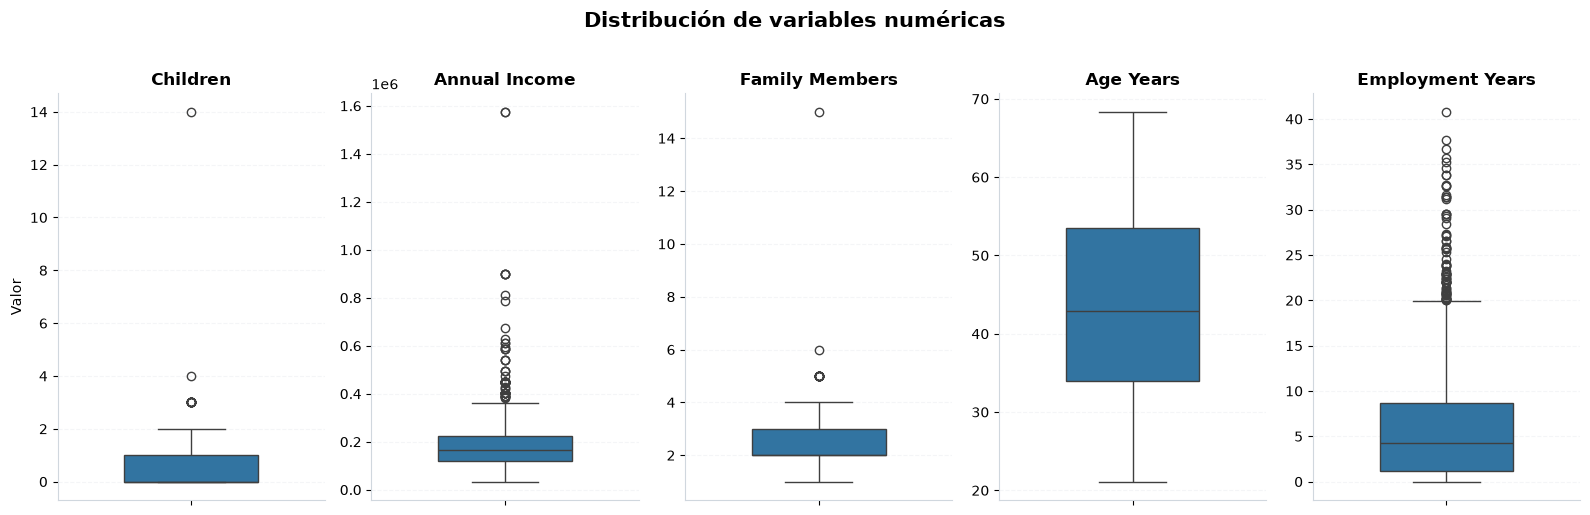

In [216]:

num_cols = [
    'children',
    'annual_income',
    'family_members',
    'age_years',
    'employment_years',
    # 'log_annual_income'
]

fig, axes = plt.subplots(
    ncols=len(num_cols),
    nrows=1,
    figsize=(16, 5)
)

for i, col in enumerate(num_cols):

    sns.boxplot(
        data=df,
        y=col,
        ax=axes[i],
        width=0.5
    )

    axes[i].set_title(
        col.replace('_', ' ').title(),
        fontsize=12,
        fontweight='bold'
    )

    axes[i].set_xlabel('')
    axes[i].set_ylabel('Valor' if i == 0 else '')

    axes[i].grid(
        axis='y',
        linestyle='--',
        alpha=0.4
    )

    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

plt.suptitle(
    'Distribución de variables numéricas',
    fontsize=15,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.show()

Vemos valores extremos en 3 variables, `children`, `family_members` y `employment_years`. Vamos a tratar los outliers con el limite IQR; sin embargo, para la ultima variable en un contexto real existe personas que trabajan por mas de 40 años. 

## Division entre Train y Split

Continuando, ahora separamos las variables predictoras de la indpendiente `label`, y usamos el metodo `stratify` para mantener la misma proporción después del split. 

In [217]:
X = df.drop(columns=['label'])
y = df['label']

# Usamos stratify para mantener la misma proporción tanto en train y test.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: filas: {X_train.shape[0]} & columnas: {X_train.shape[1]}")
print(f"test: filas: {X_test.shape[0]} & columnas: {X_test.shape[1]}")
print()
print("Train balance:", y_train.value_counts(normalize=True))
print()
print("Test balance:", y_test.value_counts(normalize=True))

Train: filas: 1238 & columnas: 17
test: filas: 310 & columnas: 17

Train balance: label
0    0.886914
1    0.113086
Name: proportion, dtype: float64

Test balance: label
0    0.887097
1    0.112903
Name: proportion, dtype: float64


## Imputación de valores faltantes 

Continuamos con la imputación de valores faltantes. Importante: los valores de imputación se obtendran de train, despues se aplicará a test. 

1. `gender` se imputará usando la moda. 
2. `annual_income` se imputará usando la mediana por tipo de ingreso.
3. `age_years` se imputará por la mediana por tipo de ingreso. 

In [218]:
X_train.isnull().sum()

gender                    6
car_owner                 0
propert_owner             0
children                  0
annual_income            18
type_income               0
education                 0
marital_status            0
housing_type              0
work_phone                0
phone                     0
email_id                  0
type_occupation           0
family_members            0
is_retired_unemployed     0
age_years                21
employment_years          0
dtype: int64

In [219]:
#1. `gender` se imputará usando la moda. 
gender_mode = X_train['gender'].mode()[0]
print("Moda GENDER (train):", gender_mode)

#2. `annual_income` se imputará usando la mediana por tipo de ingreso.
income_medians = X_train.groupby('type_income')['annual_income'].median()
print("\nMedianas de ingreso por type_Income (train):\n", income_medians)

#3. `age_years` se imputará por la mediana por tipo de ingreso. 
age_medians = X_train.groupby('type_income')['age_years'].median()
print("\nMedianas de edad por type_Income (train):\n", age_medians)


Moda GENDER (train): F

Medianas de ingreso por type_Income (train):
 type_income
Commercial associate    180000.0
Pensioner               135000.0
State servant           180000.0
Working                 157500.0
Name: annual_income, dtype: float64

Medianas de edad por type_Income (train):
 type_income
Commercial associate    39.660274
Pensioner               60.279452
State servant           41.493151
Working                 39.650685
Name: age_years, dtype: float64


In [220]:
# Creamos una funcion para imputar tanto en train y test 

def apply_imputation(X, gender_mode, income_medians, age_medians):
    
    X = X.copy()
    
    X['gender'] = X['gender'].fillna(gender_mode)

    X['annual_income'] = X['annual_income'].fillna(X['type_income'].map(income_medians))
    
    X['age_years'] = X['age_years'].fillna(X['type_income'].map(age_medians))
    
    return X

# Hacemos la imputacion en train y test
X_train = apply_imputation(X_train, gender_mode, income_medians, age_medians)
X_test = apply_imputation(X_test, gender_mode, income_medians, age_medians)

print("\nMissing tras imputacion (train):\n", X_train.isna().sum().sum())
print("Missing tras imputacion (test):\n", X_test.isna().sum().sum())


Missing tras imputacion (train):
 0
Missing tras imputacion (test):
 0


## Capping - Imputación de outliers 

A continuación imputaremos los outliers usando el rango intercuartílico (IQR) - winsorización a las siguientes 3 variables:`children`, `annual_income` & `family_members`

In [221]:
# Valores antes de la winsorización
num_cols_outliers = ['children', 'annual_income', 'family_members', 'annual_income']
print(X_train[num_cols_outliers].describe())


         children  annual_income  family_members  annual_income
count  1238.00000   1.238000e+03     1238.000000   1.238000e+03
mean      0.42811   1.894188e+05        2.168013   1.894188e+05
std       0.80575   1.147369e+05        0.980428   1.147369e+05
min       0.00000   3.780000e+04        1.000000   3.780000e+04
25%       0.00000   1.215000e+05        2.000000   1.215000e+05
50%       0.00000   1.575000e+05        2.000000   1.575000e+05
75%       1.00000   2.250000e+05        3.000000   2.250000e+05
max      14.00000   1.575000e+06       15.000000   1.575000e+06


In [222]:
def compute_iqr_bounds(df: pd.DataFrame, cols: list[str], k: float = 1.5) -> dict:
    """Calcula los límites IQR (Tukey) por columna, ajustados SOLO con el df que se pase (ej. train)."""
    bounds = {}
    for col in cols:
        q1, q3 = df[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        bounds[col] = {
            "Q1": q1, "Q3": q3, "IQR": iqr,
            "lower": q1 - k * iqr,
            "upper": q3 + k * iqr,
        }
    return bounds


def cap_outliers(df: pd.DataFrame, bounds: dict) -> pd.DataFrame:
    """Aplica capping (winsorización) usando límites ya calculados. No recalcula nada -> apto para test."""
    df = df.copy()
    for col, b in bounds.items():
        df[col] = df[col].clip(lower=b["lower"], upper=b["upper"])
    return df


def outlier_report(df: pd.DataFrame, bounds: dict) -> pd.DataFrame:
    """Tabla resumen: cuántos outliers hay en df según los bounds dados."""
    rows = []
    for col, b in bounds.items():
        n_out = ((df[col] < b["lower"]) | (df[col] > b["upper"])).sum()
        rows.append({"variable": col, **b, "n_outliers": n_out, "pct_outliers": round(n_out / len(df) * 100, 2)})
    return pd.DataFrame(rows)

In [223]:
bounds = compute_iqr_bounds(X_train, num_cols_outliers, k=1.5)   # fit SOLO train

print("Outliers detectados en train:")
display(outlier_report(X_train, bounds))

X_train = cap_outliers(X_train, bounds)   # aplica
X_test = cap_outliers(X_test, bounds)     # mismos bounds de train, sin fuga

print("\nDESPUES de capping (train):")
print(X_train[num_cols_outliers].describe())

Outliers detectados en train:


,variable,Q1,Q3,IQR,lower,upper,n_outliers,pct_outliers
0,children,0.0,1.0,1.0,-1.5,2.5,15,1.21
1,annual_income,121500.0,225000.0,103500.0,-33750.0,380250.0,56,4.52
2,family_members,2.0,3.0,1.0,0.5,4.5,15,1.21



DESPUES de capping (train):
          children  annual_income  family_members  annual_income
count  1238.000000    1238.000000     1238.000000    1238.000000
mean      0.412359  182323.443053        2.153069  182323.443053
std       0.687244   81528.648991        0.893135   81528.648991
min       0.000000   37800.000000        1.000000   37800.000000
25%       0.000000  121500.000000        2.000000  121500.000000
50%       0.000000  157500.000000        2.000000  157500.000000
75%       1.000000  225000.000000        3.000000  225000.000000
max       2.500000  380250.000000        4.500000  380250.000000


Verificamos con un boxplot la winsorización, y efectivamente ya no tenemos outliers, excepto por la variable `employment_years`

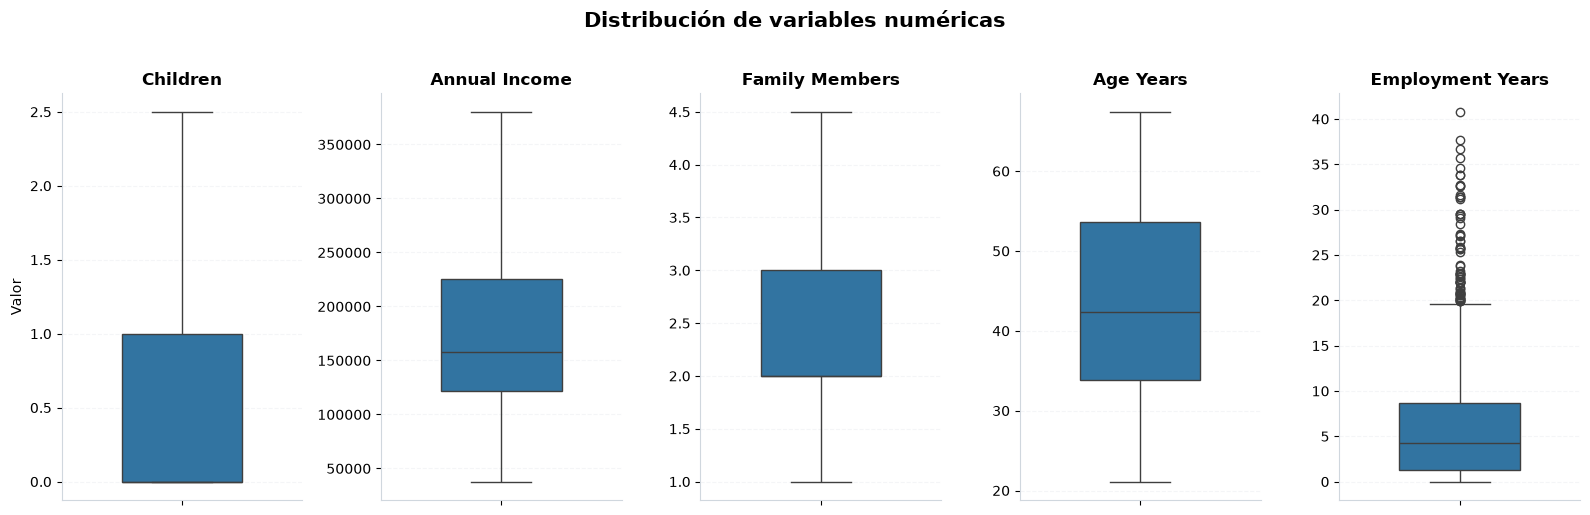

In [224]:
num_cols = ['children','annual_income','family_members','age_years','employment_years']

fig, axes = plt.subplots(
    ncols=len(num_cols),
    nrows=1,
    figsize=(16, 5)
)

for i, col in enumerate(num_cols):

    sns.boxplot(
        data=X_train,
        y=col,
        ax=axes[i],
        width=0.5
    )

    axes[i].set_title(
        col.replace('_', ' ').title(),
        fontsize=12,
        fontweight='bold'
    )

    axes[i].set_xlabel('')
    axes[i].set_ylabel('Valor' if i == 0 else '')

    axes[i].grid(
        axis='y',
        linestyle='--',
        alpha=0.4
    )

    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

plt.suptitle(
    'Distribución de variables numéricas',
    fontsize=15,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.show()

A continuación graficaremos nuestro mapa de calor para verificar si existe correlación entre nuestras variables numéricas.  

In [225]:
# Definimos nuestras variables por tipo

num_cols = ['family_members','annual_income' ,'children','age_years', 'employment_years']
cat_cols = ['gender', 'type_income','education', 'marital_status', 'housing_type', 'type_occupation']
bin_cols = ['car_owner', 'propert_owner', 'work_phone', 'phone', 'email_id']

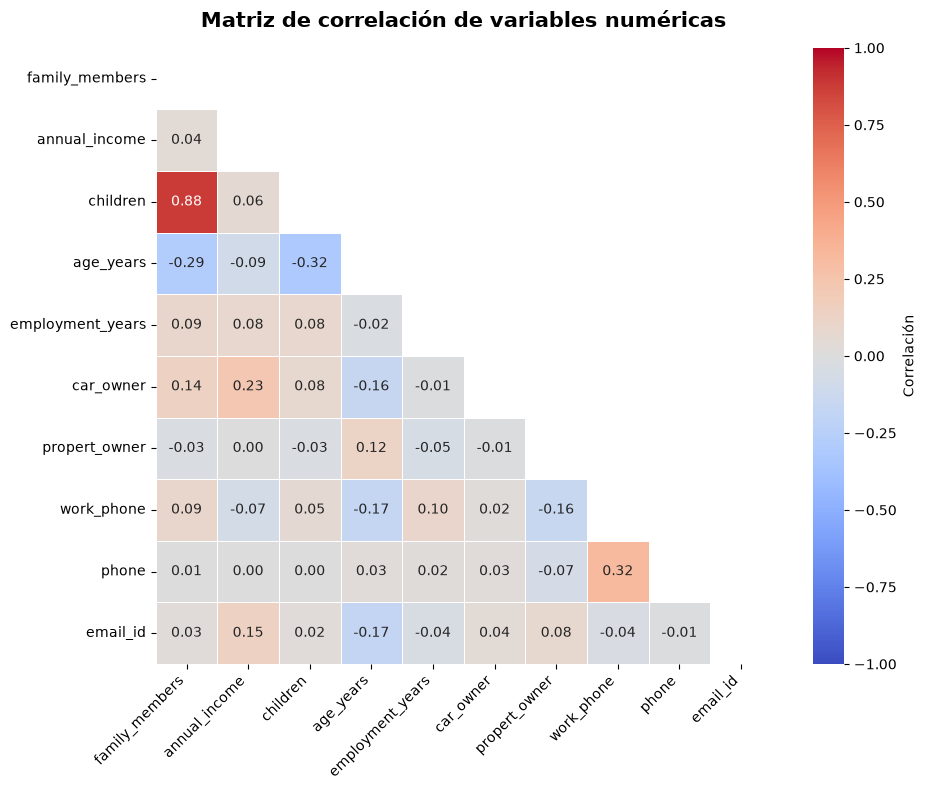

In [226]:
variables = num_cols + bin_cols

correlation_matrix = X_train[variables].corr()

# Máscara para ocultar la parte superior
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Correlación"}
)

plt.title(
    "Matriz de correlación de variables numéricas",
    fontsize=15,
    fontweight="bold",
    pad=15
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

Observamos que existe una correlación postiva entre las variables `children` y `family_members`, esto ya lo habiamos visto en el EDA, ahora aplicaremos el VIF para decidir si es conveniente eliminar una de ellas o no. 

## Analisis del VIF (Variance Inflation Factor) - multicolinealidad

In [227]:
# importamos librerias
from statsmodels.stats.outliers_influence import variance_inflation_factor

variables = num_cols + bin_cols

#aplicamos solo en entrenamiento. 
num_cols_vif = [column for column in variables]
X_vif = X_train[num_cols_vif].dropna()


X_vif_const = pd.concat([pd.Series(1.0, index=X_vif.index, name='const'), X_vif], axis=1)

vif_data = pd.DataFrame()
vif_data['Variable'] = X_vif_const.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif_const.values, i) for i in range(X_vif_const.shape[1])]

vif_data = vif_data[vif_data['Variable'] != 'const']  # descartamos la fila de la constante
vif_data.sort_values('VIF', ascending=False)

,Variable,VIF
3,children,4.478952
1,family_members,4.432798
4,age_years,1.236324
8,work_phone,1.204415
9,phone,1.126947
6,car_owner,1.111120
2,annual_income,1.101797
10,email_id,1.068064
7,propert_owner,1.046325
5,employment_years,1.030961


Un VIF > 5, podria afectar a nuestro modelo. Sin embargo, observamos tanto `children` y `family_members` no superan ese umbral y continuaremos usando las variables para entrenar el modelo. 

## One-hot Encodding

A continuacion transformaremos nuestras variables categoricas a números binarios. Solo aplicaremos a train, luego ajustaremos a test con reindex para evitar categorias nuevas no vistas. 

In [228]:
# drop_first=True elimina la primera columna para evitar la trampa de multicolinealidad
X_train_enc = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test_enc = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)

# Alineamos las columnas del Train/Test
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

# Verificamos si tienen las mismas columnas
print("Shapes:", X_train_enc.shape, X_test_enc.shape)
print("Columnas iguales:", list(X_train_enc.columns) == list(X_test_enc.columns))

Shapes: (1238, 39) (310, 39)
Columnas iguales: True


## Escalado de variables

Usaremos `standarscaler` para ajustrar y transformar nuestras variables numéricas para que tengan una media de 0 y una std de 1. Ajustaremos solo a train, y luego transformaremos a test.

In [229]:
scaler = StandardScaler()
X_train_enc[num_cols] = scaler.fit_transform(X_train_enc[num_cols])
X_test_enc[num_cols] = scaler.transform(X_test_enc[num_cols]) 

print(X_train_enc[num_cols].describe())  # media ~0, std ~1
print(X_train_enc.isna().sum().sum(), X_test_enc.isna().sum().sum())  # deben ser 0
print(list(X_train_enc.columns) == list(X_test_enc.columns))  # deben ser iguales

       family_members  annual_income      children     age_years  \
count    1.238000e+03   1.238000e+03  1.238000e+03  1.238000e+03   
mean    -1.951410e-16   8.537418e-17  5.739441e-17 -8.609161e-17   
std      1.000404e+00   1.000404e+00  1.000404e+00  1.000404e+00   
min     -1.291557e+00  -1.773387e+00 -6.002601e-01 -1.954374e+00   
25%     -1.714537e-01  -7.463392e-01 -6.002601e-01 -8.597054e-01   
50%     -1.714537e-01  -3.045981e-01 -6.002601e-01 -1.316541e-01   
75%      9.486500e-01   5.236663e-01  8.554147e-01  8.371960e-01   
max      2.628806e+00   2.428674e+00  3.038927e+00  2.028938e+00   

       employment_years  
count      1.238000e+03  
mean       1.721832e-17  
std        1.000404e+00  
min       -9.148168e-01  
25%       -7.266907e-01  
50%       -2.706894e-01  
75%        3.724155e-01  
max        5.173516e+00  
0 0
True


In [230]:
# Realizamos copia de seguridad
X_train = X_train_enc.copy()
X_test = X_test_enc.copy()

print("X_train_final:", X_train.shape, " X_test_final:", X_test.shape)
X_train.head()

X_train_final: (1238, 39)  X_test_final: (310, 39)


,car_owner,propert_owner,children,annual_income,work_phone,phone,email_id,family_members,is_retired_unemployed,age_years,...,type_occupation_Core staff,type_occupation_Drivers,type_occupation_High skill tech staff,type_occupation_Laborers,type_occupation_Managers,type_occupation_Medicine staff,type_occupation_Other,type_occupation_Sales staff,type_occupation_Security staff,type_occupation_Unknown
310,0,0,-0.600260,-0.580686,0,0,0,-0.171454,0,0.271955,...,False,True,False,False,False,False,False,False,False,False
1484,1,1,-0.600260,-0.580686,1,0,0,-0.171454,0,-0.901174,...,True,False,False,False,False,False,False,False,False,False
1210,0,0,-0.600260,-0.856774,0,0,0,-0.171454,0,-1.332585,...,False,False,False,True,False,False,False,False,False,False
829,1,0,-0.600260,-0.028510,1,0,0,-0.171454,0,-0.451384,...,False,True,False,False,False,False,False,False,False,False
53,1,0,0.855415,-0.580686,0,0,0,0.948650,0,-1.509297,...,False,False,False,True,False,False,False,False,False,False


## Entrenamiento y Benchmark de modélos básicos.

A continuación entranaremos nuestros modelos básicos. Vamos a priorizar `Recall` porque estamos en la busqueda de morosos, ya que recall hace una muy buena pregunta: De todos los morosos reales, ¿Cuántos detectó el modelo?.

Además, teniendo en cuenta lo siguiente: 

- Falsos negativos -> El modelo dice que es un buen pagador, pero en realidad era moroso --> costo $8.000

- Falsos positivo -> El modelo dice que es moroso, pero en realidad no era buen pagador --> costo $8.000

In [231]:
from sklearn.metrics import roc_auc_score, recall_score, f1_score

# Definición de Modelos (Añadimos class_weight='balanced' por los morosos)
modelos = {
    "Logistica" : LogisticRegression(
        max_iter = 1000,
        class_weight = 'balanced',
        random_state = 42,
        #C=0.01
    ),

    "Árbol" : DecisionTreeClassifier(
        max_depth = 5,
        class_weight = 'balanced',
        random_state = 42
    ),

    "Random Forest Base" : RandomForestClassifier(
        n_estimators = 100,
        class_weight = 'balanced',
        random_state = 42
    )
}

# predicciones_basicas = {}

# for nombre, modelo in modelos.items():
#     #1. Entrenar
#     modelo.fit(X_train, y_train)

#     # 2. Obtener probabilidades de la clase positiva (moroso) - AUC
#     probs = modelo.predict_proba(X_test)[:,1]

#     # 3. Obtener predicciones 0/1 usando el umbral por defecto - recall - F1
#     preds = modelo.predict(X_test)

#     #4. Guardamos en el diccionario
#     predicciones_basicas[nombre] = {
#         'modelo':modelo,
#         'probs':probs,
#         'preds':preds
#         }
#     print(f"{nombre}:entrenado")

In [232]:
def entrenar_y_evaluar(modelos_dict, X_train, y_train, X_test, y_test):
    """Entrena cada modelo, guarda predicciones/probabilidades. Devuelve el diccionario de predicciones."""
    predicciones = {}
    for nombre, modelo in modelos_dict.items():
        modelo.fit(X_train, y_train)  # si el modelo ya viene entrenado (ej. best_estimator_), fit() no hace daño, ya converge igual
        probs = modelo.predict_proba(X_test)[:, 1]
        preds = modelo.predict(X_test)
        predicciones[nombre] = {'modelo': modelo, 'probs': probs, 'preds': preds}
        print(f"{nombre}: listo")
    return predicciones

def calcular_metricas(y_true, preds, probs):
    return {
        "ROC-AUC": roc_auc_score(y_true, probs),
        "Recall": recall_score(y_true, preds),
        "F1-score": f1_score(y_true, preds),
        "Accuracy": accuracy_score(y_true, preds)
    }

def tabla_benchmark(predicciones, y_test, ordenar_por=('Recall', 'ROC-AUC')):
    """Arma la tabla de métricas (%) a partir de un diccionario de predicciones."""
    filas = []
    for nombre, mod in predicciones.items():
        m = calcular_metricas(y_test, mod['preds'], mod['probs'])
        m['Modelo'] = nombre
        filas.append(m)

    df = pd.DataFrame(filas)[['Modelo', 'ROC-AUC', 'Recall', 'F1-score', 'Accuracy']]
    cols = ['ROC-AUC', 'Recall', 'F1-score', 'Accuracy']
    df[cols] = df[cols].mul(100).round(2)
    
    return df.sort_values(list(ordenar_por), ascending=False).reset_index(drop=True)

def elegir_mejor_modelo(benchmark_df, overfit_df, gap_maximo=10.5):
    """Aplica la regla de decision: filtra por Gap<=umbral, ordena por Recall y desempata por ROC-AUC."""
    tabla = benchmark_df.merge(overfit_df[['Modelo', 'Gap ROC-AUC']], on='Modelo')
    candidatos = tabla[tabla['Gap ROC-AUC'] <= gap_maximo].sort_values(
        ['Recall', 'ROC-AUC'], ascending=[False, False]
    )
    print("Candidatos válidos (Gap ROC-AUC <= {}):".format(gap_maximo))
    display(candidatos)
    return candidatos.iloc[0]['Modelo']

In [233]:
modelos_basicos = entrenar_y_evaluar(modelos,X_train, y_train, X_test, y_test)
benchmark = tabla_benchmark(modelos_basicos, y_test)
display(benchmark.style.background_gradient(cmap='Greens', subset=['ROC-AUC','Recall','F1-score','Accuracy']))


Logistica: listo


Árbol: listo
Random Forest Base: listo


,Modelo,ROC-AUC,Recall,F1-score,Accuracy
0,Logistica,71.220000,71.430000,33.110000,67.420000
1,Random Forest Base,85.550000,51.430000,63.160000,93.230000
2,Árbol,64.970000,42.860000,25.860000,72.260000


Observamos que tenemos un `Recall` de 71.32% en el modelo de `Logística`. Sin embargo, tenemos que plantearnos algunas preguntas antes de aceptar este modelo. ¿El modelo esta sobre ajustado? ¿Las coeficientes son interpretables y tienen sentido de negocio?. Para ellos realizaremos un análisis de overfitting. 

In [234]:
# Funcion overfitting
def diagnosticar_overfitting(modelos_dict, X_train, y_train, X_test, y_test):
    filas = []
    for nombre, modelo in modelos_dict.items():
        pt, prt = modelo.predict(X_train), modelo.predict_proba(X_train)[:, 1]
        pte, prte = modelo.predict(X_test), modelo.predict_proba(X_test)[:, 1]
        filas.append({
            'Modelo': nombre,
            'Recall Train': recall_score(y_train, pt), 'Recall Test': recall_score(y_test, pte),
            'ROC-AUC Train': roc_auc_score(y_train, prt), 'ROC-AUC Test': roc_auc_score(y_test, prte),
        })
    df = pd.DataFrame(filas)
    df['Gap Recall'] = df['Recall Train'] - df['Recall Test']
    df['Gap ROC-AUC'] = df['ROC-AUC Train'] - df['ROC-AUC Test']
    return df

Analicemos las dos modelos que tienen mejor rendimiento en el `Recall`, RL no parece presentar evidencias de overfitting, a pesar que tienen signos negativos, pero son minimos. Por otra parte, RF si presenta signos de overffitng, por que es normal en este tipo de modelos. 

In [235]:
diagnosticar_overfitting(modelos,X_train, y_train, X_test, y_test)

,Modelo,Recall Train,Recall Test,ROC-AUC Train,ROC-AUC Test,Gap Recall,Gap ROC-AUC
0,Logistica,0.635714,0.714286,0.708798,0.712208,-0.078571,-0.003409
1,Árbol,0.592857,0.428571,0.743719,0.649662,0.164286,0.094057
2,Random Forest Base,1.000000,0.514286,0.999756,0.855532,0.485714,0.144224


Continuamos con el análisis de los coeficientes de `RL`, pues observamos que el modelo asigna mucho peso a variables categóricas por lo cual aplicaremos un ajuste en ridge para que tenga mas sentido de negocio!


In [236]:
modelo_lr = modelos_basicos["Logistica"]["modelo"]

coeficientes = pd.DataFrame({
    'Feature' : X_train.columns,
    'Coeficiente': modelo_lr.coef_[0]
})

coeficientes["Abs_Coeficiente"] = coeficientes["Coeficiente"].abs()


coeficientes.sort_values('Abs_Coeficiente', ascending=False).head(15)

,Feature,Coeficiente,Abs_Coeficiente
12,type_income_Pensioner,1.718190,1.718190
8,is_retired_unemployed,-1.691250,1.691250
16,education_Lower secondary,1.494840,1.494840
19,marital_status_Separated,1.289935,1.289935
26,housing_type_With parents,-1.166867,1.166867
20,marital_status_Single / not married,1.149128,1.149128
13,type_income_State servant,-0.787947,0.787947
23,housing_type_Municipal apartment,0.719754,0.719754
21,marital_status_Widow,0.665652,0.665652
22,housing_type_House / apartment,-0.613928,0.613928


## Optimización de modelos Basicos

Ahora optimizaremos los modelos básicos usando `GridSearchCV` con el fin de optener los mejores hiperparámetros mediante validación cruzada. Además, optimizaremos `Regresion Logistica` buscando mejores parámetros para C.

In [237]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 1) Logística: R2
param_grid_lr = {'C': [0.001, 0.01, 0.05, 0.1, 0.5, 1.0]}

grid_lr = GridSearchCV(
    LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42),
    param_grid_lr, 
    scoring='recall', 
    cv=cv, 
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)

# 2) Árbol: limitar profundidad Y tamaño mínimo de hoja
param_grid_arbol = {
    'max_depth': [3, 4, 5, 6],
    'min_samples_leaf': [5, 10, 20, 30],
}

grid_arbol = GridSearchCV(
    DecisionTreeClassifier(
        class_weight='balanced',
        random_state=42),
    param_grid_arbol, 
    scoring='recall', 
    cv=cv, 
    n_jobs=-1
)
grid_arbol.fit(X_train, y_train)

# 3 Random Forest: el mas urgente (Recall train=1.0) ----
param_grid_rf = {
    'max_depth': [4, 6, 8, 10],
    'min_samples_leaf': [5, 10, 20],
    'n_estimators': [200],
}
grid_rf = GridSearchCV(
    RandomForestClassifier(
        class_weight='balanced',
        random_state=42),
    param_grid_rf,
    scoring='recall',
    cv=cv, n_jobs=-1
)
grid_rf.fit(X_train, y_train)

print("Mejores parámetros Logística:", grid_lr.best_params_)
print("Mejores parámetros Árbol:", grid_arbol.best_params_)
print("Mejores parámetros Random Forest :", grid_rf.best_params_)


Mejores parámetros Logística: {'C': 0.01}
Mejores parámetros Árbol: {'max_depth': 3, 'min_samples_leaf': 30}
Mejores parámetros Random Forest : {'max_depth': 8, 'min_samples_leaf': 20, 'n_estimators': 200}


Tras aplicar la optimizacion de los tres modelos, ahora observamos que el `Random Forest` tiene mejor desempeño en Recall y ROC-AUC. Sin embargo, `Regresion Logistica` tiene el mismo recall que RF. 

In [238]:
modelos_opt= {
    "Logistica optimizado": grid_lr.best_estimator_,
    "Árbol optimizado": grid_arbol.best_estimator_,
    "Random Forest optimizado": grid_rf.best_estimator_,
}

modelos_basicos_opt = entrenar_y_evaluar(modelos_opt,X_train, y_train, X_test, y_test)
benchmark = tabla_benchmark(modelos_basicos_opt, y_test)
display(benchmark.style.background_gradient(cmap='Greens', subset=['ROC-AUC','Recall','F1-score','Accuracy']))

Logistica optimizado: listo
Árbol optimizado: listo
Random Forest optimizado: listo


,Modelo,ROC-AUC,Recall,F1-score,Accuracy
0,Random Forest optimizado,75.210000,68.570000,34.530000,70.650000
1,Logistica optimizado,64.810000,68.570000,28.400000,60.970000
2,Árbol optimizado,65.070000,48.570000,28.810000,72.900000


Nuevamente analizamos si existe overfitting en los modelos optimizados. Observamos quien tiene mejor rendimiento es RL. Por otra parte, RF a mejorado bastante.

In [239]:
diagnosticar_overfitting(modelos_opt,X_train, y_train, X_test, y_test)

,Modelo,Recall Train,Recall Test,ROC-AUC Train,ROC-AUC Test,Gap Recall,Gap ROC-AUC
0,Logistica optimizado,0.628571,0.685714,0.654492,0.648104,-0.057143,0.006388
1,Árbol optimizado,0.514286,0.485714,0.682416,0.650701,0.028571,0.031715
2,Random Forest optimizado,0.764286,0.685714,0.853067,0.752104,0.078571,0.100963


Tras la optimización del modelo de `Regresion Logistica`, observamos que la mayoria de variables con mayor peso tienen una interpretación coherente con la práctica de *credit scoring*: mayor antigüedad laboral, ser propietario de vivienda y mayor nivel educativo 
se asocian a menor riesgo, mientras que menor nivel educativo y tipos de vivienda social se asocian a mayor riesgo — todo alineado con la intuición de negocio.

sin embargo, dos hallazgos requieren atención: 

- `age_years` aparece con signo positivo (mayor edad → mayor riesgo), lo cual es contraintuitivo. 
  Es probable que esté capturando un efecto residual debido a su correlación con `employment_years` 
  y `type_income_Pensioner` (ya detectada en el análisis de VIF), más que una relación causal real.
- `gender_M` aparece como variable relevante. Más allá de su validez estadística, el uso de género 
  en modelos de scoring crediticio está sujeto a restricciones normativas en muchas jurisdicciones 
  (riesgo de discriminación). 
  
Se recomienda evaluar excluir esta variable del modelo final y medir el impacto en Recall antes de cualquier despliegue real. (eliminar esas variables o no)

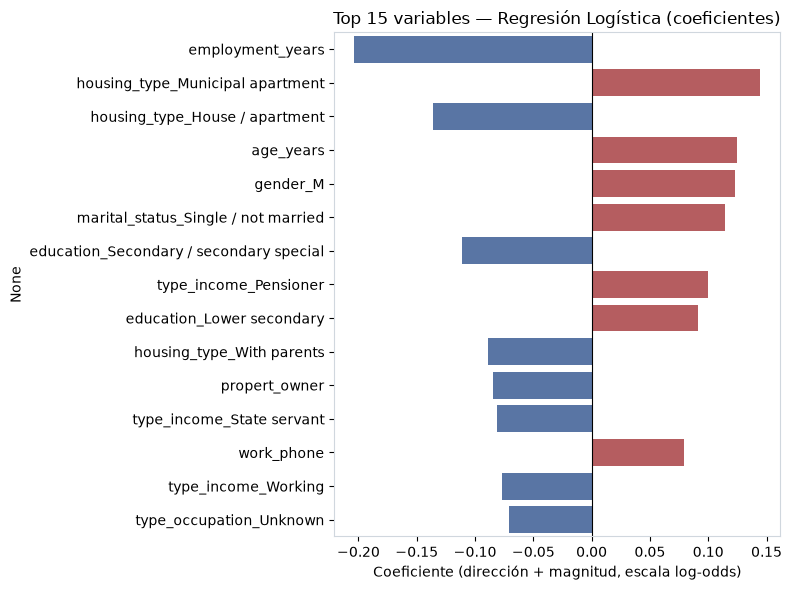

employment_years                          -0.203418
housing_type_Municipal apartment           0.144164
housing_type_House / apartment            -0.136123
age_years                                  0.124978
gender_M                                   0.122913
marital_status_Single / not married        0.114434
education_Secondary / secondary special   -0.111344
type_income_Pensioner                      0.099466
education_Lower secondary                  0.091309
housing_type_With parents                 -0.088924
propert_owner                             -0.084412
type_income_State servant                 -0.080811
work_phone                                 0.079485
type_income_Working                       -0.077173
type_occupation_Unknown                   -0.071185
dtype: float64


In [240]:
lr_final = grid_lr.best_estimator_

coefs_lr = pd.Series(lr_final.coef_[0], index=X_train.columns)

top_15 = coefs_lr.reindex(coefs_lr.abs().sort_values(ascending=False).head(15).index)

plt.figure(figsize=(8,6))
colors = ['#C44E52' if v > 0 else '#4C72B0' for v in top_15.values]  # rojo = sube riesgo, azul = baja riesgo
sns.barplot(x=top_15.values, y=top_15.index, palette=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title("Top 15 variables — Regresión Logística (coeficientes)")
plt.xlabel("Coeficiente (dirección + magnitud, escala log-odds)")
plt.tight_layout()
plt.show()

print(top_15)

Al quitar gender_M, vemos que no afecta al Recall, entonces es una buena opción poder excluir esa variable. Pero eso ya será en proximas mejoras del modelo.

In [241]:
X_train_sin_genero = X_train.drop(columns=['gender_M'])
X_test_sin_genero = X_test.drop(columns=['gender_M'])

lr_sin_genero = LogisticRegression(
    C=grid_lr.best_params_['C'], 
    class_weight='balanced',
    random_state=42,
    max_iter=1000)

lr_sin_genero.fit(X_train_sin_genero, y_train)
recall_sin_genero = recall_score(y_test, lr_sin_genero.predict(X_test_sin_genero))

print("Recall CON gender_M:", 
    recall_score(
        y_test, 
        modelos_basicos_opt['Logistica optimizado']['preds']))
print("Recall SIN gender_M:", recall_sin_genero)

Recall CON gender_M: 0.6857142857142857
Recall SIN gender_M: 0.6857142857142857


Odds Ratio para mejor interpretabilidad del modelo de `Regresion Logistica`

In [242]:
tabla_interpretacion = pd.DataFrame({
    'Coeficiente': top_15,
    'Odds Ratio': np.exp(top_15),
    'Efecto (%)': (np.exp(top_15) - 1) * 100
}).round(3)

tabla_interpretacion['Dirección'] = np.where(
    tabla_interpretacion['Coeficiente'] > 0, 'Aumenta riesgo ⬆️', 'Reduce riesgo ⬇️'
)

display(tabla_interpretacion.sort_values('Coeficiente', key=abs, ascending=False))

,Coeficiente,Odds Ratio,Efecto (%),Dirección
employment_years,-0.203,0.816,-18.406,Reduce riesgo ⬇️
housing_type_Municipal apartment,0.144,1.155,15.507,Aumenta riesgo ⬆️
housing_type_House / apartment,-0.136,0.873,-12.726,Reduce riesgo ⬇️
age_years,0.125,1.133,13.312,Aumenta riesgo ⬆️
gender_M,0.123,1.131,13.079,Aumenta riesgo ⬆️
marital_status_Single / not married,0.114,1.121,12.124,Aumenta riesgo ⬆️
education_Secondary / secondary special,-0.111,0.895,-10.537,Reduce riesgo ⬇️
type_income_Pensioner,0.099,1.105,10.458,Aumenta riesgo ⬆️
education_Lower secondary,0.091,1.096,9.561,Aumenta riesgo ⬆️
housing_type_With parents,-0.089,0.915,-8.508,Reduce riesgo ⬇️


In [243]:
random_forest = benchmark.iloc[0]['Modelo']
print('modelo seleccionado por Recall: ', random_forest)
rf_modelo = modelos_basicos_opt[random_forest]['modelo']
rf_proba = modelos_basicos_opt[random_forest]['probs']
rf_pred = modelos_basicos_opt[random_forest]['preds']

modelo seleccionado por Recall:  Random Forest optimizado


Ahora analizamos las variables mas importantes de Random Forest, lo cual tiene mucho sentido y criterio de negocio.



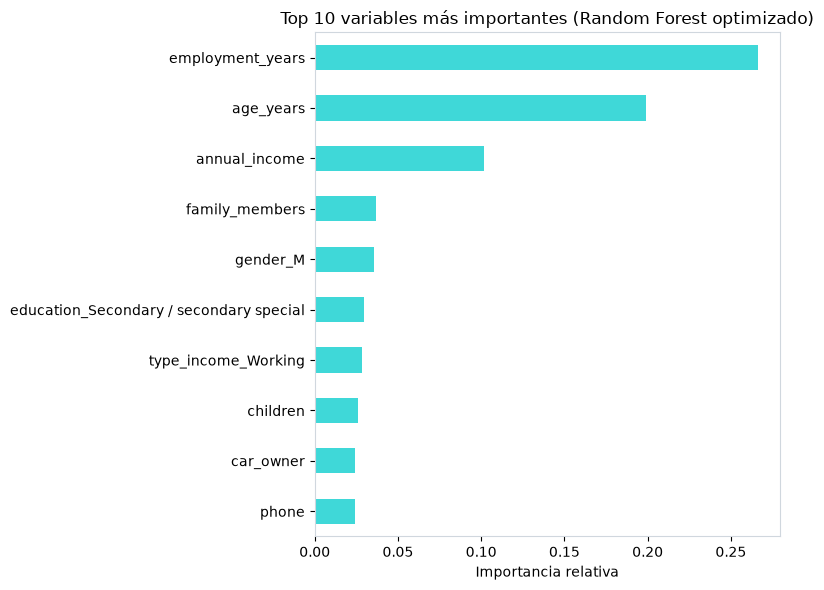

employment_years                           0.266194
age_years                                  0.199155
annual_income                              0.101405
family_members                             0.036788
gender_M                                   0.035879
education_Secondary / secondary special    0.029865
type_income_Working                        0.028658
children                                   0.026027
car_owner                                  0.024136
phone                                      0.023929
dtype: float64

In [244]:
importancias = pd.Series(rf_modelo.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
importancias.head(10).sort_values().plot(kind='barh', color='#3FD8D8')
plt.title(f'Top 10 variables más importantes ({random_forest})')
plt.xlabel('Importancia relativa')
plt.tight_layout()
plt.show()

importancias.head(10)

El comportamiento del modelo esta dominado por la antiguedad laboral y la edad, seguidas por características sociodemográficas, nivel de ingreso, tipo de ingreso, estado civil y vivienda. Hasta cierto punto tiene sentido de negocio, a excepcion de gender_M, queda para evaluación. 

`employment_years`: Muestra una fuerte influencia sobre las predicciones, lo cual tiene mucho sentido, a menor nivel de antiguedad laboral se asocian a una tasa mayor de impago. 


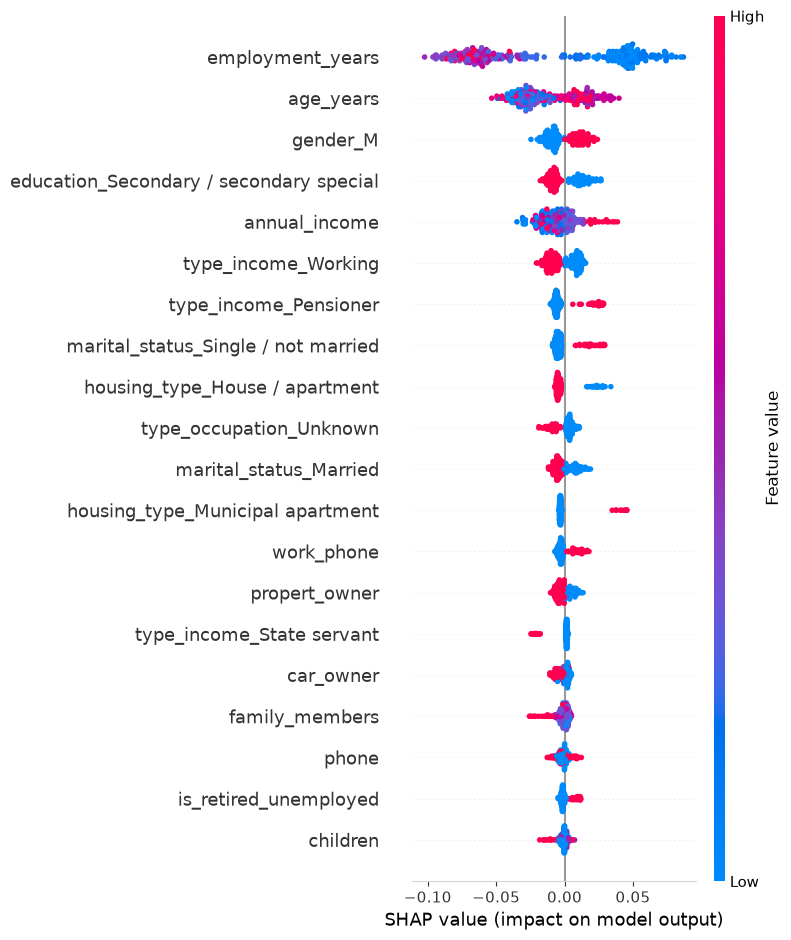

In [245]:
import shap

explainer_rf = shap.TreeExplainer(rf_modelo)
shap_values = explainer_rf.shap_values(X_test)
shap_values_1 = shap_values[:, :, 1]

shap.summary_plot(shap_values_1, X_test, show=False)
plt.tight_layout()
plt.show()

shap_df = pd.DataFrame(
    shap_values_1,
    columns=X_test.columns,
    index=X_test.index
)

Curva ROC

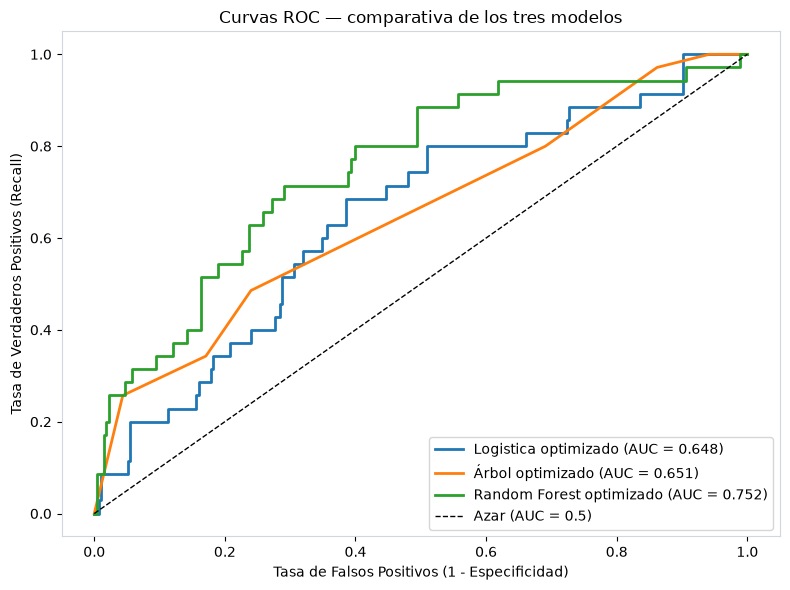

In [246]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 6))


for nombre, mod in modelos_basicos_opt.items():
    fpr, tpr, _ = roc_curve(y_test, mod['probs'])
    auc = roc_auc_score(y_test, mod['probs'])
    plt.plot(fpr, tpr, label=f"{nombre} (AUC = {auc:.3f})", linewidth=2)

plt.plot([0,1], [0,1], 'k--', linewidth=1, label='Azar (AUC = 0.5)')
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
plt.ylabel('Tasa de Verdaderos Positivos (Recall)')
plt.title('Curvas ROC — comparativa de los tres modelos')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

Matriz de confusión 

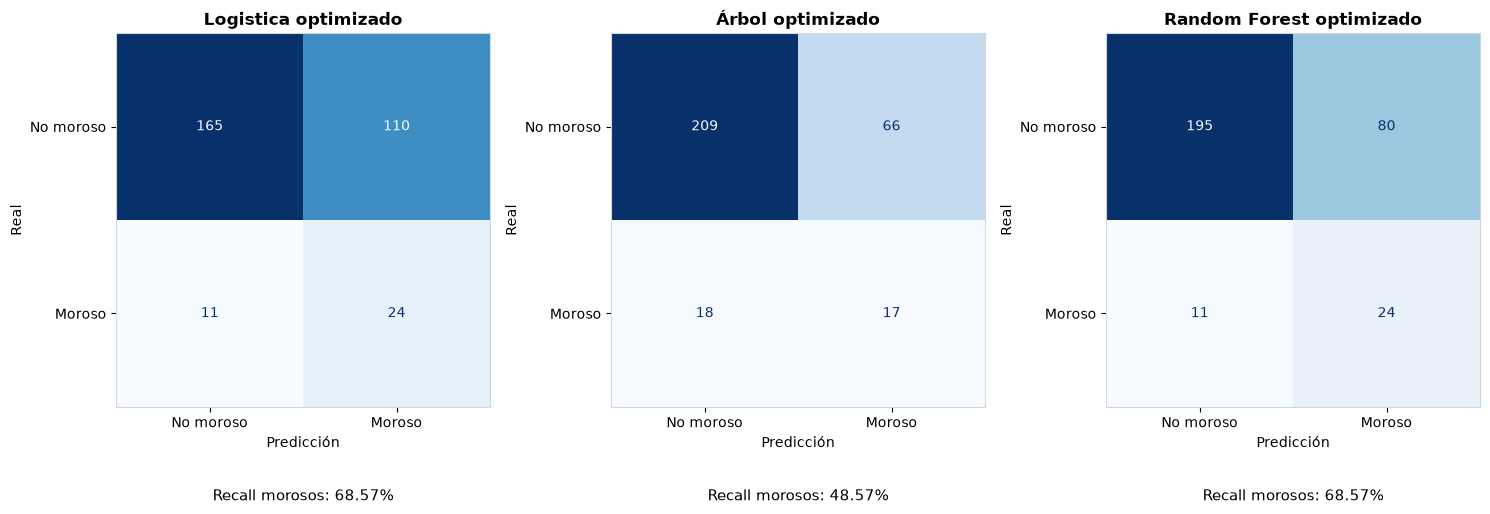

In [247]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(nrows=1,ncols=3,figsize=(15, 5))

for ax, (nombre, datos) in zip(axes, modelos_basicos_opt.items()):
    cm = confusion_matrix(y_test,datos["preds"])

    # Recall de la clase Moroso = 1
    tn, fp, fn, tp = cm.ravel()
    recall = tp / (tp + fn)

    # Crear matriz visual
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["No moroso", "Moroso"])
    disp.plot(ax=ax,cmap="Blues",colorbar=False)
    # Título
    ax.set_title(nombre,fontsize=12,fontweight="bold")
    # Etiquetas
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real")
    # Recall debajo del gráfico
    ax.text(
        0.5,
        -0.25,
        f"Recall morosos: {recall:.2%}",
        transform=ax.transAxes,
        ha="center",
        fontsize=11
    )

plt.tight_layout()
plt.show()

## XGBoost y LightGBM

Nuestro objetivo sigue siendo el mismo, detectar morosos. Para ello usaremos algoritmos de Gradient Boosting basado en arboles de decisión. priorizaremos `recall` ya que estamos en la caza de morosos

In [248]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV

# compensamos el desbalanceo de clases (solo ~11% son morosos)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid_xgb = {
    'max_depth': [3, 4, 5], # profundidad de arboles
    'learning_rate': [0.01, 0.05, 0.1], # aporte de cada arbol al modelo final
    'n_estimators': [100, 200], # cantidad de arboles que construirá el modelo
    'min_child_weight': [1, 5, 10], # "¿Hay suficiente evidencia para seguir dividiendo esta rama?"
    'reg_lambda': [1, 5, 10], # l2 regularizacion
    'subsample': [0.8, 1.0],
}

grid_xgb = GridSearchCV(
    XGBClassifier(
        random_state=42, 
        n_jobs=1, 
        eval_metric='logloss', # evaluacion de probabilidades del modelo
        scale_pos_weight=scale_pos_weight), # para balancear la variable objetivo
    param_grid_xgb, 
    scoring='recall', 
    cv=cv, 
    n_jobs=-1  # cv = tu StratifiedKFold, no el entero 5
)


param_grid_lgbm = {
    'num_leaves': [7, 15, 31],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200],
    'min_child_samples': [10, 20, 30],
    'reg_lambda': [1, 5, 10],
}
grid_lgbm = GridSearchCV(
    LGBMClassifier(
        random_state=42, 
        n_jobs=1, 
        class_weight='balanced', 
        verbosity=-1),
    param_grid_lgbm, 
    scoring='recall', 
    cv=cv, 
    n_jobs=-1
)


grid_xgb.fit(X_train, y_train)

# LightGBM

grid_lgbm.fit(X_train, y_train)

print("Mejores parámetros XGBoost:", grid_xgb.best_params_)
print("Mejores parámetros LightGBM:", grid_lgbm.best_params_)

Mejores parámetros XGBoost: {'learning_rate': 0.01, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 200, 'reg_lambda': 1, 'subsample': 1.0}
Mejores parámetros LightGBM: {'learning_rate': 0.01, 'min_child_samples': 30, 'n_estimators': 200, 'num_leaves': 31, 'reg_lambda': 5}


`LightGBM` tiene mejor comportamiento que `XGBoost`, sin embargo no se acercan a los modelos basicos optimizados.

In [249]:
modelos_xg_lgbm = { 
    "XGBoost optimizado": grid_xgb.best_estimator_,
    "LightGBM optimizado": grid_lgbm.best_estimator_
}

modelos_avz = entrenar_y_evaluar(modelos_xg_lgbm,X_train, y_train, X_test, y_test)
benchmark = tabla_benchmark(modelos_avz, y_test)
display(benchmark.style.background_gradient(cmap='Greens', subset=['ROC-AUC','Recall','F1-score','Accuracy']))

XGBoost optimizado: listo
LightGBM optimizado: listo


,Modelo,ROC-AUC,Recall,F1-score,Accuracy
0,LightGBM optimizado,80.720000,60.000000,36.520000,76.450000
1,XGBoost optimizado,72.650000,54.290000,30.650000,72.260000


Ambos modelos nos indica que estan sobre ajustados. 

In [250]:
diagnosticar_overfitting(modelos_xg_lgbm,X_train, y_train, X_test, y_test)

,Modelo,Recall Train,Recall Test,ROC-AUC Train,ROC-AUC Test,Gap Recall,Gap ROC-AUC
0,XGBoost optimizado,0.871429,0.542857,0.912695,0.726494,0.328571,0.186202
1,LightGBM optimizado,0.935714,0.600000,0.958515,0.807169,0.335714,0.151347


Benchmarking final de modelos construidos. 

1. Modelo con mejor desempeño: `Random Forest`, con un Recall de 68.6% y un Roc - AUC de 75%.
2. En el análisis de overfiting: `Random Forest` se mantinene con un gap aceptable de 10.1pts, dentro del rango aceptable. 

En conclusión: Se usará `Randon Forest` para evaluar los umbrales optimos y la optimización. 

In [251]:
modelos_finales = {
    "Logistica optimizado": grid_lr.best_estimator_,
    "Árbol optimizado": grid_arbol.best_estimator_,
    "Random Forest optimizado": grid_rf.best_estimator_,
    "XGBoost optimizado": grid_xgb.best_estimator_,
    "LightGBM optimizado": grid_lgbm.best_estimator_,
}

predicciones_finales = entrenar_y_evaluar(modelos_finales, X_train, y_train, X_test, y_test)
benchmark_final = tabla_benchmark(predicciones_finales, y_test)
overfit_final = diagnosticar_overfitting(modelos_finales, X_train, y_train, X_test, y_test)
overfit_final['Gap ROC-AUC'] = (overfit_final['Gap ROC-AUC'] * 100).round(2)  # a % para que combine con benchmark

display(benchmark_final.style.background_gradient(cmap='Greens', subset=['ROC-AUC','Recall','F1-score','Accuracy']))
display(overfit_final)

mejor_modelo_nombre = elegir_mejor_modelo(benchmark_final, overfit_final)
mejor_modelo = predicciones_finales[mejor_modelo_nombre]['modelo']
mejor_proba = predicciones_finales[mejor_modelo_nombre]['probs']
mejor_pred = predicciones_finales[mejor_modelo_nombre]['preds']

print("Modelo final seleccionado:", mejor_modelo_nombre)

Logistica optimizado: listo
Árbol optimizado: listo
Random Forest optimizado: listo
XGBoost optimizado: listo
LightGBM optimizado: listo


,Modelo,ROC-AUC,Recall,F1-score,Accuracy
0,Random Forest optimizado,75.210000,68.570000,34.530000,70.650000
1,Logistica optimizado,64.810000,68.570000,28.400000,60.970000
2,LightGBM optimizado,80.720000,60.000000,36.520000,76.450000
3,XGBoost optimizado,72.650000,54.290000,30.650000,72.260000
4,Árbol optimizado,65.070000,48.570000,28.810000,72.900000


,Modelo,Recall Train,Recall Test,ROC-AUC Train,ROC-AUC Test,Gap Recall,Gap ROC-AUC
0,Logistica optimizado,0.628571,0.685714,0.654492,0.648104,-0.057143,0.64
1,Árbol optimizado,0.514286,0.485714,0.682416,0.650701,0.028571,3.17
2,Random Forest optimizado,0.764286,0.685714,0.853067,0.752104,0.078571,10.10
3,XGBoost optimizado,0.871429,0.542857,0.912695,0.726494,0.328571,18.62
4,LightGBM optimizado,0.935714,0.600000,0.958515,0.807169,0.335714,15.13


Candidatos válidos (Gap ROC-AUC <= 10.5):


,Modelo,ROC-AUC,Recall,F1-score,Accuracy,Gap ROC-AUC
0,Random Forest optimizado,75.21,68.57,34.53,70.65,10.10
1,Logistica optimizado,64.81,68.57,28.40,60.97,0.64
4,Árbol optimizado,65.07,48.57,28.81,72.90,3.17


Modelo final seleccionado: Random Forest optimizado


## Manejo de umbrales óptimos segun detalles del negocio.

Ahora probaremos umbrales posibles con el fin de quedarnos con el umbral que minimice el costo real para el banco. 

Umbral óptimo según coste de negocio: 0.41
Coste estimado con umbral óptimo: 84,800$
Coste estimado con umbral por defecto (0.50): 120,000$
Ahorro potencial: 35,200$ solo por elegir bien el umbral


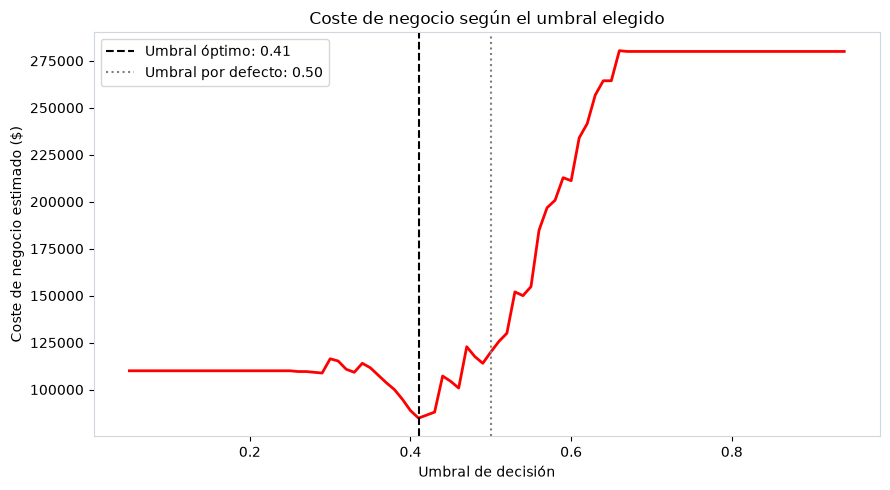

In [283]:
probs_mejor_modelo = mejor_modelo.predict_proba(X_test)[:, 1]

umbrales = np.arange(0.05, 0.95, 0.01)
costes_por_umbral = []

for u in umbrales:
    preds_u = (probs_mejor_modelo >= u).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds_u).ravel()
    coste_total = fn * COSTE_FALSO_NEGATIVO + fp * COSTE_FALSO_POSITIVO
    costes_por_umbral.append(coste_total)

costes_por_umbral = np.array(costes_por_umbral)
umbral_optimo = umbrales[np.argmin(costes_por_umbral)]
coste_optimo = costes_por_umbral.min()
coste_umbral_050 = costes_por_umbral[np.argmin(np.abs(umbrales - 0.5))]


print(f"Umbral óptimo según coste de negocio: {umbral_optimo:.2f}")
print(f"Coste estimado con umbral óptimo: {coste_optimo:,.0f}$")
print(f"Coste estimado con umbral por defecto (0.50): {coste_umbral_050:,.0f}$")
print(f"Ahorro potencial: {coste_umbral_050 - coste_optimo:,.0f}$ solo por elegir bien el umbral")

plt.figure(figsize=(9, 5))
plt.plot(umbrales, costes_por_umbral, color='red', lw=2)
plt.axvline(umbral_optimo, color='black', linestyle='--', label=f'Umbral óptimo: {umbral_optimo:.2f}')
plt.axvline(0.5, color='gray', linestyle=':', label='Umbral por defecto: 0.50')
plt.xlabel('Umbral de decisión')
plt.ylabel('Coste de negocio estimado ($)')
plt.title('Coste de negocio según el umbral elegido')
plt.legend()
plt.tight_layout()
plt.show()

El umbral óptimo según coste de negocio es de 0.41, este umbral nos permitirá un ahorro potencial de 35200$ un aproximado ~29%.

## Benchmark final en dÓlares.

Comparación de los 5 enfoques de modelos optimizados en dólares. 

In [286]:
filas_coste = []

# 1) Los 5 modelos finales, cada uno a su umbral por defecto (0.50)
for nombre, resultado in predicciones_finales.items():
    tn, fp, fn, tp = confusion_matrix(y_test, resultado['preds']).ravel()
    coste = fn * COSTE_FALSO_NEGATIVO + fp * COSTE_FALSO_POSITIVO
    filas_coste.append({
        'Modelo': nombre,
        'Falsos Negativos': fn,
        'Falsos Positivos': fp,
        'Coste Estimado ($)': coste,
        'Accuracy': round(100 * (tn + tp) / len(y_test), 2)
    })

preds_umbral_optimo = (probs_mejor_modelo >= umbral_optimo).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, preds_umbral_optimo).ravel()
filas_coste.append({
    'Modelo': f'{mejor_modelo_nombre} (umbral óptimo = {umbral_optimo:.2f})',
    'Falsos Negativos': fn,
    'Falsos Positivos': fp,
    'Coste Estimado ($)': fn * COSTE_FALSO_NEGATIVO + fp * COSTE_FALSO_POSITIVO,
    'Accuracy': round(100 * (tn + tp) / len(y_test), 2)
})

df_coste_negocio = pd.DataFrame(filas_coste).set_index('Modelo').sort_values('Coste Estimado ($)')
display(df_coste_negocio.style.format({'Coste Estimado ($)': '{:,.0f} $'}).background_gradient(cmap='RdYlGn_r', subset=['Coste Estimado ($)']))

,Falsos Negativos,Falsos Positivos,Coste Estimado ($),Accuracy
Modelo,,,,
Random Forest optimizado (umbral óptimo = 0.41),2,172,"84,800 $",43.870000
Random Forest optimizado,11,80,"120,000 $",70.650000
Logistica optimizado,11,110,"132,000 $",60.970000
LightGBM optimizado,14,59,"135,600 $",76.450000
XGBoost optimizado,16,70,"156,000 $",72.260000
Árbol optimizado,18,66,"170,400 $",72.900000


## Simulación básica. 

Cogeremos 10 clientes del set de test y ver que decisión tomaría el modelo ganador.

In [287]:
def simular_produccion(probs, y_test, umbral, X_test, ids_test=None, n_muestra=10, random_state=42):
    """Simula decisiones de aprobación/rechazo aplicando el umbral óptimo a una muestra de solicitudes."""
    simulacion = pd.DataFrame({
        'ID_Cliente': ids_test.values if ids_test is not None else X_test.index,
        'Probabilidad de Impago (%)': (probs * 100).round(1),
        'Label real': y_test.values,
    })
    simulacion['Decisión (umbral óptimo)'] = np.where(
        simulacion['Probabilidad de Impago (%)'] / 100 >= umbral, 'Rechazado ❌', 'Aprobado ✅'
    )
    muestra = simulacion.sample(n_muestra, random_state=random_state).reset_index(drop=True)
    return simulacion, muestra


simulacion_completa, muestra_simulacion = simular_produccion(
    probs_mejor_modelo, y_test, umbral_optimo, X_test, n_muestra=10
)

display(muestra_simulacion[['ID_Cliente', 'Probabilidad de Impago (%)', 'Decisión (umbral óptimo)']])

,ID_Cliente,Probabilidad de Impago (%),Decisión (umbral óptimo)
0,1279,47.2,Rechazado ❌
1,975,62.8,Rechazado ❌
2,427,51.8,Rechazado ❌
3,15,52.6,Rechazado ❌
4,287,51.0,Rechazado ❌
5,1466,47.6,Rechazado ❌
6,685,39.7,Aprobado ✅
7,1472,37.8,Aprobado ✅
8,814,39.4,Aprobado ✅
9,463,38.5,Aprobado ✅


In [289]:
n_aprobados = (simulacion_completa['Decisión (umbral óptimo)'] == 'Aprobado ✅').sum()
n_rechazados = (simulacion_completa['Decisión (umbral óptimo)'] == 'Rechazado ❌').sum()
total = len(simulacion_completa)

print(f"Modelo usado: {mejor_modelo_nombre} | Umbral óptimo: {umbral_optimo:.2f}")
print(f"Solicitudes evaluadas: {total}")
print(f"Aprobadas: {n_aprobados} ({n_aprobados/total*100:.1f}%)")
print(f"Rechazadas: {n_rechazados} ({n_rechazados/total*100:.1f}%)")

# Verificacion de calidad: de los morosos REALES, ¿cuántos detectó (rechazó) el modelo?
morosos_reales = simulacion_completa[simulacion_completa['Label real'] == 1]
tasa_deteccion = (morosos_reales['Decisión (umbral óptimo)'] == 'Rechazado ❌').mean()
print(f"\nDe los morosos reales en el set de test, el modelo detecta (rechaza) al {tasa_deteccion*100:.1f}%")

Modelo usado: Random Forest optimizado | Umbral óptimo: 0.41
Solicitudes evaluadas: 310
Aprobadas: 106 (34.2%)
Rechazadas: 204 (65.8%)

De los morosos reales en el set de test, el modelo detecta (rechaza) al 94.3%


"De cada 100 solicitudes, el modelo aprueba ~34 y rechaza ~66. A cambio de ese filtro más estricto, detecta al 94.3% de los morosos reales — dejando escapar solo 2 de cada 35 — lo que reduce el costo esperado de la cartera en aproximadamente 29% frente a usar el umbral por defecto."

### Memo de cierre formato Comité de Riesgos

*Para: Dirección de Riesgos*
*De: Equipo de Modelización*
*Asunto: Selección de modelo de Credit Scoring*

Se han evaluado cinco enfoques bajo un marco de coste que valora un impago no detectado en 8.000$ frente a 400$ por el rechazo de un buen cliente, una proporción de 20:1 acorde a la realidad del negocio: Regresión Logística, Árbol de Decisión y Random Forest como modelos base, y XGBoost y LightGBM tuneados con Grid Search (usando Recall como criterio de ajuste, nuestra prioridad real: cazar morosos).

**Recomendación:** Random Forest optimizado cuyo Recall fue de 68.57%, superó a XGBoost(54%) y a LightGBM(60%)  y se impone también sobre arbol optimizados en Recall (48.6%). Sin embargo, Regresión Logística, iguala en recall a Randomo Forest optimizado, pero en poder de ranking (AUC) Random forest optimizado 75.21% es superior frente al 64,81% de Regresión logística. Aplicando además el umbral de decisión que minimiza el coste (0,41 en vez del 0,50 por defecto), el coste estimado baja a 84.800$, frente a 120.000$ con el umbral por defecto.
